In [1]:
# Cell 1 — Imports
import sys
sys.path.append("..")

import numpy as np
import pickle
import warnings
warnings.filterwarnings("ignore")

from sklearn.metrics import (balanced_accuracy_score,
    confusion_matrix, matthews_corrcoef, f1_score)

import matplotlib.pyplot as plt

from shared.config import *
from shared.metrics import (ids_evaluate,
                             tune_threshold_proba)
from shared.plots import (plot_confusion_matrix,
                           plot_pr_curve, plot_frontier)

print("Imports OK")

Config loaded successfully
Imports OK


In [2]:
# Cell 2 — Load all results
with open("models/splits.pkl", "rb") as f:
    splits = pickle.load(f)
y_val  = splits["y_val"]
y_test = splits["y_test"]

with open("models/ml/opt_results.pkl", "rb") as f:
    opt_data = pickle.load(f)

with open("models/ml/trained_models.pkl", "rb") as f:
    trained = pickle.load(f)

with open("models/ml/best_xgb.pkl", "rb") as f:
    best_xgb = pickle.load(f)

with open("models/dl/dl_results.pkl", "rb") as f:
    dl_data = pickle.load(f)

X_val  = splits["X_val"]
X_test = splits["X_test"]

proba_mlp_test = dl_data["proba_mlp_test"]
proba_mlp_val  = dl_data["proba_mlp_val"]
proba_optuna   = opt_data["proba_optuna"]

print("All results loaded")

All results loaded


In [3]:
# Cell 3 — Collect validation + test probabilities
with open("models/ml/random_forest.pkl", "rb") as f:
    rf = pickle.load(f)
with open("models/ml/lightgbm.pkl", "rb") as f:
    lgbm = pickle.load(f)

proba_xgb_test  = best_xgb.predict_proba(X_test)[:, 1]
proba_rf_test   = rf.predict_proba(X_test)[:, 1]
proba_lgbm_test = lgbm.predict_proba(X_test)[:, 1]

proba_xgb_val   = best_xgb.predict_proba(X_val)[:, 1]
proba_rf_val    = rf.predict_proba(X_val)[:, 1]
proba_lgbm_val  = lgbm.predict_proba(X_val)[:, 1]

print("Probabilities collected")

Probabilities collected


In [6]:
print(trained.keys())

dict_keys([])


In [7]:
print("opt_data keys:", opt_data.keys())
print("dl_data keys:", dl_data.keys())

# Check if rf/lgbm are saved separately
import os
print("\nmodels/ml/ contents:")
for f in os.listdir("models/ml/"):
    print(" ", f)

opt_data keys: dict_keys(['optuna_m', 'fi_m', 'uni_m', 'pca_m', 'pso_m', 'smote_m', 'spw_m', 'study', 'best_params', 'top_features', 'pso_features', 'proba_optuna'])
dl_data keys: dict_keys(['mlp_m', 'proba_mlp_test', 'proba_mlp_val', 'th_mlp', 'train_losses', 'val_losses', 'lr_history', 'best_epoch'])

models/ml/ contents:
  random_forest.pkl
  decision_tree.pkl
  knn.pkl
  naive_bayes.pkl
  svm.pkl
  xgboost.pkl
  lightgbm.pkl
  all_results.pkl
  all_probas.pkl
  trained_models.pkl
  best_xgb.pkl
  optuna_study.pkl
  xgb_fi.pkl
  xgb_uni.pkl
  selector_uni.pkl
  xgb_pca.pkl
  pca_scaler.pkl
  pca.pkl
  xgb_pso.pkl
  pso_features.pkl
  xgb_smote.pkl
  xgb_spw.pkl
  opt_results.pkl


In [4]:
# Cell 4 — Weighted fusion (ML ensemble)
w = {"xgb": 0.40, "rf": 0.20, "lgbm": 0.20}

proba_hybrid_test = (
    w["xgb"]  * proba_xgb_test  +
    w["rf"]   * proba_rf_test   +
    w["lgbm"] * proba_lgbm_test
)
proba_hybrid_val = (
    w["xgb"]  * proba_xgb_val  +
    w["rf"]   * proba_rf_val   +
    w["lgbm"] * proba_lgbm_val
)

def fast_tune_threshold(proba, y_true, n=81):
    thresholds = np.linspace(0.1, 0.9, n)
    y_arr = y_true.values if hasattr(y_true, 'values') else y_true
    scores = []
    for t in thresholds:
        p = (proba >= t).astype(np.int8)
        tp = ((p==1) & (y_arr==1)).sum()
        fp = ((p==1) & (y_arr==0)).sum()
        fn = ((p==0) & (y_arr==1)).sum()
        tn = ((p==0) & (y_arr==0)).sum()
        scores.append(0.5*(tp/(tp+fn+1e-9) + tn/(tn+fp+1e-9)))
    return float(thresholds[np.argmax(scores)])

th_hybrid     = fast_tune_threshold(proba_hybrid_val, y_val)
y_pred_hybrid = (proba_hybrid_test >= th_hybrid).astype(int)

hybrid_m = ids_evaluate("Hybrid (ML+DL)", y_test.values,
                         proba_hybrid_test, y_pred_hybrid, th_hybrid)
print("Hybrid ensemble metrics:")
for k, v in hybrid_m.items():
    print(f"  {k}: {v}")

Hybrid ensemble metrics:
  Model: Hybrid (ML+DL)
  Balanced Acc: 0.976
  F1 Macro: 0.977
  MCC: 0.954
  Attack Recall: 0.9593
  Benign Recall: 0.9928
  Attack Precision: 0.9643
  Benign Precision: 0.9917
  FAR: 0.0072
  FNR: 0.0407
  ROC-AUC: 0.9924
  PR-AUC: 0.9838


In [6]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import numpy as np

print("Training anomaly detector (Isolation Forest)...")

scaler_if = StandardScaler()

X_train_arr = X_train.values
y_train_arr = y_train.values
X_benign    = X_train_arr[y_train_arr == 0]

SAMPLE_IF = 200_000
rng_if    = np.random.RandomState(RANDOM_STATE)
idx_if    = rng_if.choice(len(X_benign),
                           SAMPLE_IF, replace=False)
X_benign_sample = scaler_if.fit_transform(
    X_benign[idx_if])

iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.1,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
iso_forest.fit(X_benign_sample)
print("Anomaly detector trained")

Training anomaly detector (Isolation Forest)...
Anomaly detector trained


In [5]:
# Load splits first
X_train = splits["X_train"]
X_val   = splits["X_val"]
X_test  = splits["X_test"]
y_train = splits["y_train"]
y_val   = splits["y_val"]
y_test  = splits["y_test"]

print(f"X_train: {X_train.shape}")
print(f"Splits loaded")

X_train: (11363049, 34)
Splits loaded


In [7]:
X_test_scaled_if = scaler_if.transform(X_test.values)
X_val_scaled_if  = scaler_if.transform(X_val.values)

anomaly_scores_test = -iso_forest.score_samples(
    X_test_scaled_if)
anomaly_scores_val  = -iso_forest.score_samples(
    X_val_scaled_if)

mms = MinMaxScaler()
anomaly_scores_test = mms.fit_transform(
    anomaly_scores_test.reshape(-1, 1)).flatten()
anomaly_scores_val  = mms.transform(
    anomaly_scores_val.reshape(-1, 1)).flatten()

print(f"Anomaly score range (test): "
      f"{anomaly_scores_test.min():.3f} — "
      f"{anomaly_scores_test.max():.3f}")

Anomaly score range (test): 0.000 — 1.000


In [8]:
w_sig  = 0.70
w_anom = 0.30

proba_hybrid_true_test = (
    w_sig  * proba_xgb_test +
    w_anom * anomaly_scores_test
)
proba_hybrid_true_val = (
    w_sig  * proba_xgb_val +
    w_anom * anomaly_scores_val
)

th_hybrid_true = fast_tune_threshold(proba_hybrid_true_val, y_val)
y_pred_hybrid_true = (proba_hybrid_true_test >= th_hybrid_true).astype(int)

hybrid_true_m = ids_evaluate(
    "Hybrid IDS (Signature+Anomaly)",
    y_test.values,
    proba_hybrid_true_test,
    y_pred_hybrid_true,
    th_hybrid_true
)

print("TRUE HYBRID IDS metrics:")
for k, v in hybrid_true_m.items():
    print(f"  {k}: {v}")

TRUE HYBRID IDS metrics:
  Model: Hybrid IDS (Signature+Anomaly)
  Balanced Acc: 0.9758
  F1 Macro: 0.9784
  MCC: 0.9569
  Attack Recall: 0.9575
  Benign Recall: 0.9941
  Attack Precision: 0.9708
  Benign Precision: 0.9914
  FAR: 0.0059
  FNR: 0.0425
  ROC-AUC: 0.9804
  PR-AUC: 0.9748


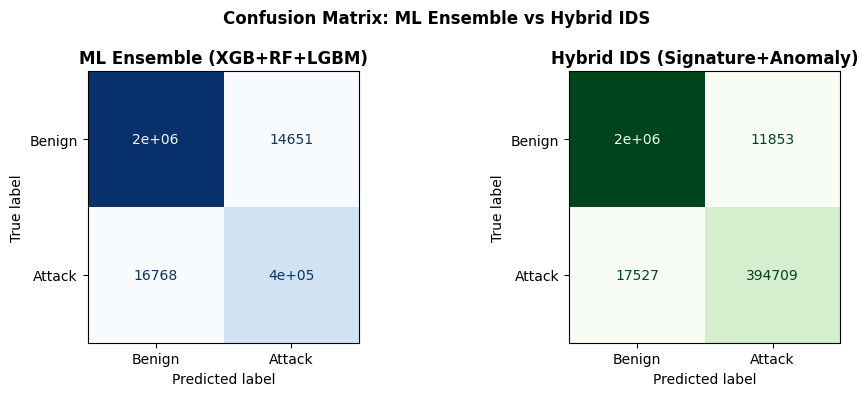

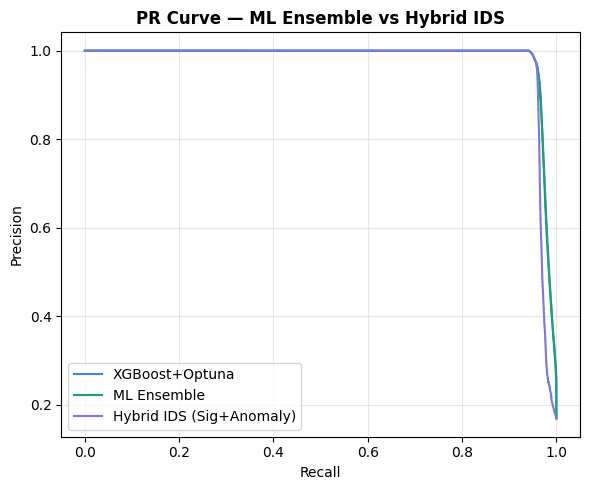

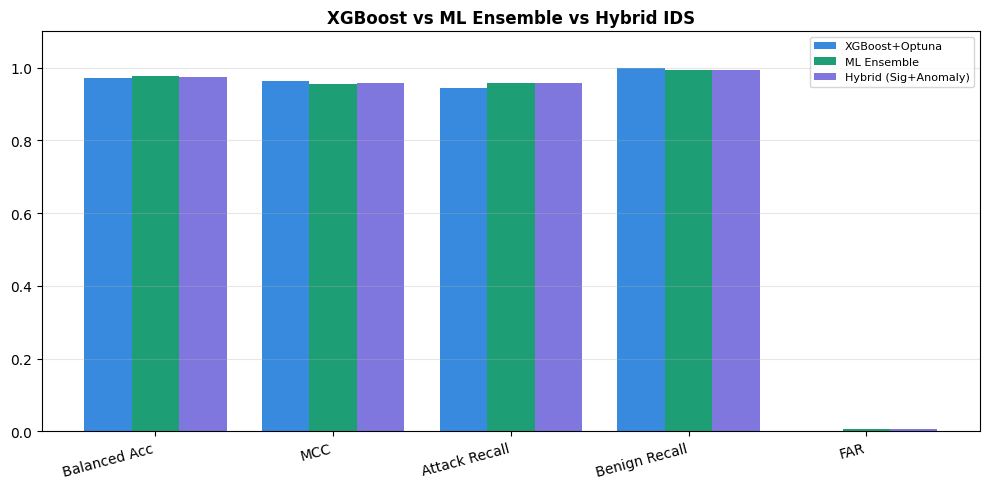

In [9]:
from sklearn.metrics import ConfusionMatrixDisplay
from shared.plots import plot_metrics_bar, plot_pr_curve

# Confusion matrix comparison
cm_sig    = confusion_matrix(y_test.values, y_pred_hybrid)
cm_hybrid = confusion_matrix(y_test.values,
                              y_pred_hybrid_true)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay(
    cm_sig, display_labels=["Benign","Attack"]
).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("ML Ensemble (XGB+RF+LGBM)",
                   fontweight="bold")
ConfusionMatrixDisplay(
    cm_hybrid, display_labels=["Benign","Attack"]
).plot(ax=axes[1], colorbar=False, cmap="Greens")
axes[1].set_title("Hybrid IDS (Signature+Anomaly)",
                   fontweight="bold")
plt.suptitle("Confusion Matrix: ML Ensemble vs Hybrid IDS",
              fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/graphs/05_hybrid_cm.png", dpi=150)
plt.show()

# PR curve
plot_pr_curve(
    y_test.values,
    {"XGBoost+Optuna"          : proba_xgb_test,
     "ML Ensemble"             : proba_hybrid_test,
     "Hybrid IDS (Sig+Anomaly)": proba_hybrid_true_test},
    title="PR Curve — ML Ensemble vs Hybrid IDS",
    save_path="outputs/graphs/05_hybrid_pr.png"
)

# Metrics bar
with open("models/ml/opt_results.pkl", "rb") as f:
    opt_data_bar = pickle.load(f)
optuna_m = opt_data_bar["optuna_m"]

KEY = ["Balanced Acc","MCC","Attack Recall",
       "Benign Recall","FAR"]
plot_metrics_bar(
    {"XGBoost+Optuna"         : optuna_m,
     "ML Ensemble"            : hybrid_m,
     "Hybrid (Sig+Anomaly)"   : hybrid_true_m},
    KEY,
    title="XGBoost vs ML Ensemble vs Hybrid IDS",
    save_path="outputs/graphs/05_single_vs_hybrid.png"
)

Reference score: 0.9754
No drift detected — model is stable


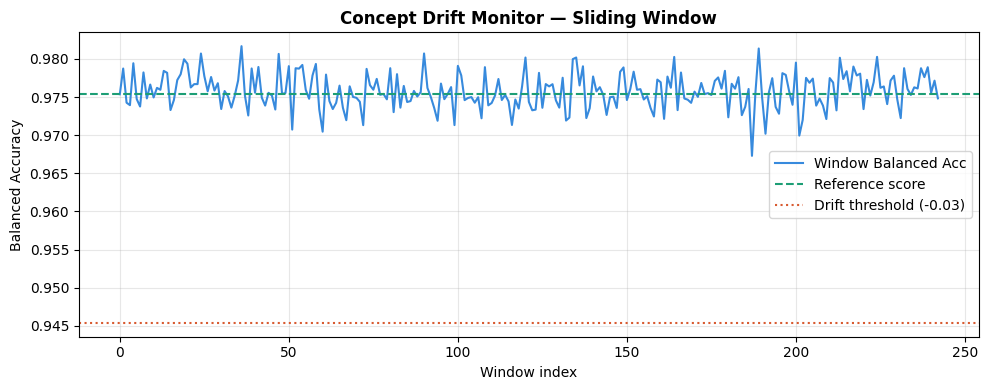

In [10]:
WINDOW_SIZE  = 10_000
DRIFT_THRESH = 0.03

n_windows  = len(y_test) // WINDOW_SIZE
y_test_arr = y_test.values
y_pred_arr = y_pred_hybrid_true

reference_score = balanced_accuracy_score(
    y_test_arr[:WINDOW_SIZE],
    y_pred_arr[:WINDOW_SIZE]
)
print(f"Reference score: {reference_score:.4f}")

window_scores  = []
drift_detected = []

for i in range(n_windows):
    start   = i * WINDOW_SIZE
    end     = start + WINDOW_SIZE
    w_score = balanced_accuracy_score(
        y_test_arr[start:end],
        y_pred_arr[start:end]
    )
    drift = (reference_score - w_score) > DRIFT_THRESH
    window_scores.append(w_score)
    drift_detected.append(drift)
    if drift:
        print(f"  Drift at window {i} "
              f"(BAcc dropped to {w_score:.4f})")

if not any(drift_detected):
    print("No drift detected — model is stable")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(window_scores, color="#378ADD",
        label="Window Balanced Acc")
ax.axhline(reference_score, color="#1D9E75",
           linestyle="--", label="Reference score")
ax.axhline(reference_score - DRIFT_THRESH,
           color="#D85A30", linestyle=":",
           label=f"Drift threshold (-{DRIFT_THRESH})")
for i, d in enumerate(drift_detected):
    if d:
        ax.axvline(i, color="#D85A30", alpha=0.4)
ax.set_xlabel("Window index")
ax.set_ylabel("Balanced Accuracy")
ax.set_title("Concept Drift Monitor — Sliding Window",
             fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("outputs/graphs/05_concept_drift.png", dpi=150)
plt.show()

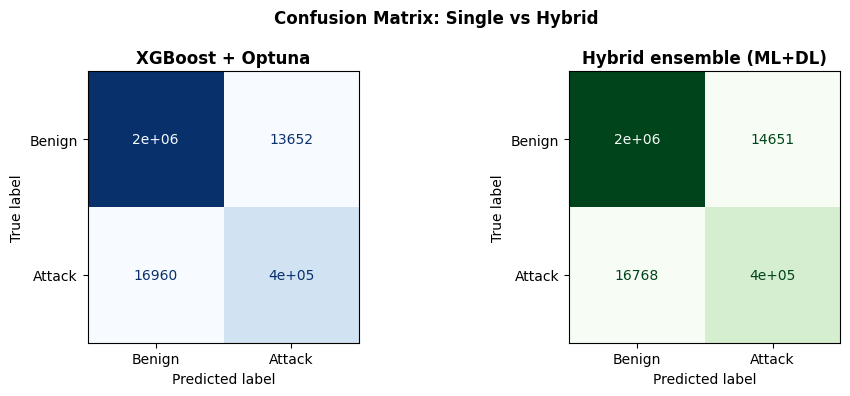

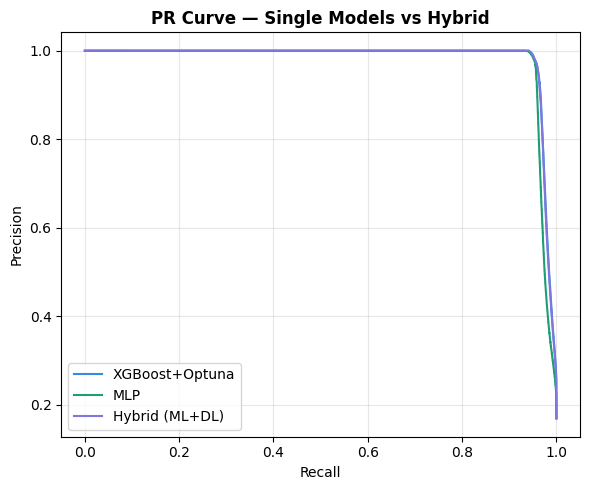

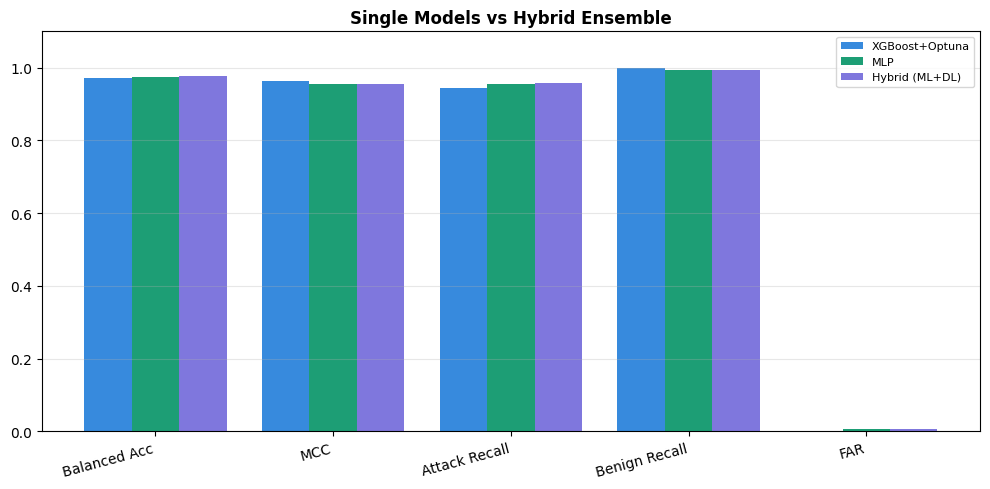

In [13]:
# Cell 5 — Hybrid vs single model comparison graphs
# Cell 5 — Hybrid vs single model comparison graphs

# ── Metrics (already in memory from Cell 2) ──────────────────────────────
optuna_m = opt_data["optuna_m"]
mlp_m    = dl_data["mlp_m"]

# ── Recompute XGBoost val/test probas from the saved model ───────────────
proba_xgb_val  = best_xgb.predict_proba(X_val)[:, 1]   # best_xgb loaded in Cell 2
proba_xgb_test = opt_data["proba_optuna"]               # this IS the xgb test proba

# ── Single-model threshold & predictions ─────────────────────────────────
th_single     = fast_tune_threshold(proba_xgb_val, y_val)
y_pred_single = (proba_xgb_test >= th_single).astype(int)

# ── Confusion matrices ────────────────────────────────────────────────────
from sklearn.metrics import ConfusionMatrixDisplay

cm_single = confusion_matrix(y_test.values, y_pred_single)
cm_hybrid = confusion_matrix(y_test.values, y_pred_hybrid)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay(cm_single, display_labels=["Benign","Attack"]).plot(
    ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("XGBoost + Optuna", fontweight="bold")
ConfusionMatrixDisplay(cm_hybrid, display_labels=["Benign","Attack"]).plot(
    ax=axes[1], colorbar=False, cmap="Greens")
axes[1].set_title("Hybrid ensemble (ML+DL)", fontweight="bold")
plt.suptitle("Confusion Matrix: Single vs Hybrid", fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/graphs/05_hybrid_cm.png", dpi=150)
plt.show()

# ── PR curve ─────────────────────────────────────────────────────────────
plot_pr_curve(
    y_test.values,
    {"XGBoost+Optuna" : proba_xgb_test,
     "MLP"            : proba_mlp_test,
     "Hybrid (ML+DL)" : proba_hybrid_test},
    title="PR Curve — Single Models vs Hybrid",
    save_path="outputs/graphs/05_hybrid_pr.png"
)

# ── Metrics bar ───────────────────────────────────────────────────────────
from shared.plots import plot_metrics_bar
KEY = ["Balanced Acc","MCC","Attack Recall","Benign Recall","FAR"]
plot_metrics_bar(
    {"XGBoost+Optuna" : optuna_m,
     "MLP"            : mlp_m,
     "Hybrid (ML+DL)" : hybrid_m},
    KEY,
    title="Single Models vs Hybrid Ensemble",
    save_path="outputs/graphs/05_single_vs_hybrid.png"
)


In [12]:
print("opt_data keys:", opt_data.keys())
print("dl_data keys:", dl_data.keys())

opt_data keys: dict_keys(['optuna_m', 'fi_m', 'uni_m', 'pca_m', 'pso_m', 'smote_m', 'spw_m', 'study', 'best_params', 'top_features', 'pso_features', 'proba_optuna'])
dl_data keys: dict_keys(['mlp_m', 'proba_mlp_test', 'proba_mlp_val', 'th_mlp', 'train_losses', 'val_losses', 'lr_history', 'best_epoch'])


Reference score: 0.9667
No drift detected — model is stable


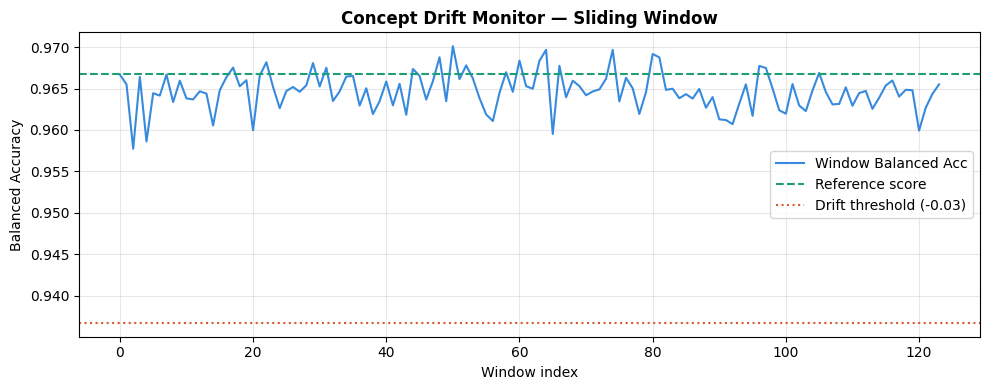

In [7]:
# Cell 6 — Concept drift detection (CDC section 5.4)
WINDOW_SIZE  = 10_000
DRIFT_THRESH = 0.03

n_windows = len(y_test) // WINDOW_SIZE
y_test_arr    = y_test.values
y_pred_arr    = y_pred_hybrid

reference_score = balanced_accuracy_score(
    y_test_arr[:WINDOW_SIZE],
    y_pred_arr[:WINDOW_SIZE]
)
print(f"Reference score: {reference_score:.4f}")

window_scores  = []
drift_detected = []

for i in range(n_windows):
    start   = i * WINDOW_SIZE
    end     = start + WINDOW_SIZE
    w_score = balanced_accuracy_score(
        y_test_arr[start:end],
        y_pred_arr[start:end]
    )
    drift = (reference_score - w_score) > DRIFT_THRESH
    window_scores.append(w_score)
    drift_detected.append(drift)
    if drift:
        print(f"  Drift at window {i} "
              f"(BAcc dropped to {w_score:.4f})")

if not any(drift_detected):
    print("No drift detected — model is stable")

# Drift monitoring plot
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(window_scores, color="#378ADD",
        label="Window Balanced Acc")
ax.axhline(reference_score, color="#1D9E75",
           linestyle="--", label="Reference score")
ax.axhline(reference_score - DRIFT_THRESH,
           color="#D85A30", linestyle=":",
           label=f"Drift threshold (-{DRIFT_THRESH})")

for i, d in enumerate(drift_detected):
    if d:
        ax.axvline(i, color="#D85A30", alpha=0.4)

ax.set_xlabel("Window index")
ax.set_ylabel("Balanced Accuracy")
ax.set_title("Concept Drift Monitor — Sliding Window",
             fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("outputs/graphs/05_concept_drift.png", dpi=150)
plt.show()

In [14]:
# Cell 7 — Save hybrid results
hybrid_data = {
    "hybrid_m"         : hybrid_m,
    "proba_hybrid_test": proba_hybrid_test,
    "proba_hybrid_val" : proba_hybrid_val,
    "th_hybrid"        : th_hybrid,
    "y_pred_hybrid"    : y_pred_hybrid,
    "drift_detected"   : drift_detected,
    "window_scores"    : window_scores,
}
with open("models/hybrid/hybrid_results.pkl", "wb") as f:
    pickle.dump(hybrid_data, f)

print("Notebook 05 complete — proceed to 06_evaluation_final.ipynb")

Notebook 05 complete — proceed to 06_evaluation_final.ipynb
